In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *

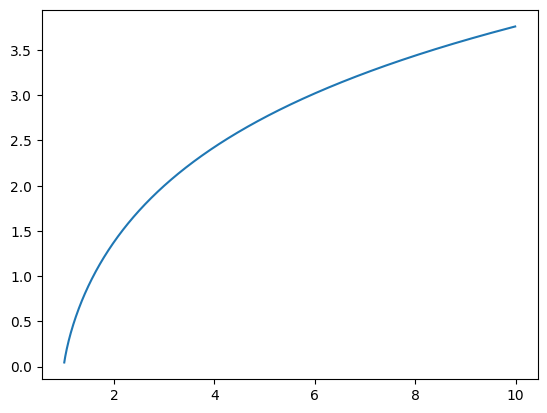

In [3]:
G = lambda X: np.array([g(x) for x in X])

X= np.arange(1.01, 10.0, 0.01)
plt.plot(X, G(X))

# Continuous-variable QKD key rates

In this notebook we are computing the secret key rates for CV-QKD protocols following the calculations in Table III (below) of Zhang et al.'s "_Continuous-variable quantum key distribution system: Past, present, and future_" (2024), __[APR version](https://pubs.aip.org/aip/apr/article/11/1/011318/3279669/Continuous-variable-quantum-key-distribution)__. 

The __[arXiv](https://arxiv.org/pdf/2310.04831)__ version does not have the table but it has an in-text explanation.

NOTE: the $G(x)$ in the table corresponds to the `g(x)` entropy function defined in `qopt_funcs`.

![alt text](zhang_table.png)

In [4]:
V = 5
T= np.linspace(0.01, 1., 5)
exc_noise = 0.1
chi = (1 - T)/T + exc_noise
a, b, c = V, T*(V + chi), np.sqrt(T*(V**2 - 1))
Delta = a**2 + b**2 - 2*c**2
D = a*b - c**2
A = (a + b*D + Delta)/(a + 1)
A_prime = (b + a*D + Delta)/(b + 1)
B = D*(b + D)/(a + 1)
B_prime = D*(a + D)/(b + 1)

## Functions for computing the key rate

- Mutual information is the (classical) expression for a bivariate Gaussian distribution, given the covariance matrix.

- Holevo bound depends on the symplectic eigenvalues of the covariance matrix, before and after (= conditioned to) the measurement. 

The expressions of the eigenvalues of the cov. mtx and of the conditional cov. mtx, are taken from Table III (To avoid confusion, the ```lambdas``` are numbered according to Zhang's notation)

All possible combinations of homo-/hetero-dyne measurement, squeezed/coherent states, direct/reverse reconciliation are considered. 

In [5]:
# i know it's a mess, i'm calling global variables inside the functions, as long as it works for now. i'll oop it eventually

def mutual_information_CV(T, states='squeezed', detection_mode='homodyne'):   # I_AB does NOT depend on the reconc scheme
    if states == 'squeezed' and detection_mode == 'homodyne':
        return 0.5*np.log2(V + chi)/(chi + 1/V)
    elif states == 'coherent' and detection_mode == 'homodyne':
        return 0.5*np.log2((V + chi)/(chi + 1))
    
    elif states == 'squeezed' and detection_mode == 'heterodyne':
        return 0.5*np.log2(T*(V + chi) + 1)/(T*(chi + 1/V) + 1)
    elif states == 'coherent' and detection_mode == 'heterodyne':
        return 0.5*np.log2(T*(V + chi) + 1)/(T*(chi + 1) + 1)
    
    else:
        raise ValueError("Invalid \'states\' or \'detection_mode\' argument")


def holevo_bound_CV(T, states='squeezed', detection_mode='homodyne', reconciliation='direct'):

    lambdas = np.zeros((13, len(T)))    # leaving the 1st one empty to use indeces from 1 to 12
    lambdas[0] = T    # to keep track of the transmittance values

    # Alice and Bob's covariance matrix eigenvalues before measurement
    lambdas[1] = np.sqrt(0.5*(Delta + np.sqrt(Delta**2 - 4*D**2)))
    lambdas[2] = np.sqrt(0.5*(Delta - np.sqrt(Delta**2 - 4*D**2)))


    # HOMODYNE measurement

    ## squeezed states
    ### direct reconciliation
    lambdas[3] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
    ### reverse reconciliation
    lambdas[4] = np.sqrt(V*(V*chi + 1)/(chi + V))

    ## coherent states
    ### direct reconciliation
    lambdas[5] = np.sqrt(0.5*(A + np.sqrt(A**2 - 4*B)))
    lambdas[6] = np.sqrt(0.5*(A - np.sqrt(A**2 - 4*B)))
    ### reverse reconciliation
    lambdas[7] = np.sqrt(V*(V*chi + 1)/(chi + V))


    # HETERODYNE measurement

    ## squeezed states
    ### direct reconciliation
    lambdas[8] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
    ### reverse reconciliation
    lambdas[9] = np.sqrt(0.5*(A_prime + np.sqrt(A_prime**2 - 4*B_prime)))
    lambdas[10] = np.sqrt(0.5*(A_prime - np.sqrt(A_prime**2 - 4*B_prime)))

    ## coherent states
    ### direct reconciliation
    lambdas[11] = T*(chi + 1)
    ### reverse reconciliation
    lambdas[12] = (T*(V*chi + 1) + 1)/(T*(V + chi) + 1)

    with np.printoptions(threshold=np.inf):
        print(lambdas)
        
    if states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[3]) 
    elif states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[4])
    
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[5]) - g(lambdas[6])
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[7])
    
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[8]) 
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[9]) - g(lambdas[10])
    
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[11])
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[12])
    
    else:
        raise ValueError("Invalid \'states\', \'detection_mode\' or \'reconciliation\' argument")



coherent homodyne direct
[[0.01       0.2575     0.505      0.7525     1.        ]
 [4.96000671 3.97530338 3.00515255 2.06219334 1.27576507]
 [1.00100671 1.03105338 1.07565255 1.14744334 1.17576507]
 [0.01023884 0.40777601 1.10055478 2.21090719 4.12310563]
 [4.88336587 3.15737065 2.29429743 1.70179011 1.21267813]
 [2.22711473 1.99918994 1.75634322 1.49449442 1.23906076]
 [1.00099999 1.02563403 1.04919909 1.0673104  1.03669109]
 [4.88336587 3.15737065 2.29429743 1.70179011 1.21267813]
 [0.01023884 0.40777601 1.10055478 2.21090719 4.12310563]
 [4.92106398 3.44539205 2.48352624 1.76919092 1.21508684]
 [1.00050155 1.0139558  1.02953829 1.04646013 1.04047122]
 [1.001      1.02575    1.0505     1.07525    1.1       ]
 [2.92258697 1.66857564 1.03979855 0.66196352 0.40983607]]
coherent homodyne reverse
[[0.01       0.2575     0.505      0.7525     1.        ]
 [4.96000671 3.97530338 3.00515255 2.06219334 1.27576507]
 [1.00100671 1.03105338 1.07565255 1.14744334 1.17576507]
 [0.01023884 0.40777

c:\Users\lmariani\My_Programs\github\qkd_networks\qopt_funcs.py:37: RuntimeWarning: divide by zero encountered in log2
  return (x+1)/2 * np.log2((x+1)/2) - (x-1)/2 * np.log2((x-1)/2)
c:\Users\lmariani\My_Programs\github\qkd_networks\qopt_funcs.py:37: RuntimeWarning: invalid value encountered in multiply
  return (x+1)/2 * np.log2((x+1)/2) - (x-1)/2 * np.log2((x-1)/2)


ValueError: Unphysical (less than 1) symplectic eigenvalues detected: min = 0.4098360655737705

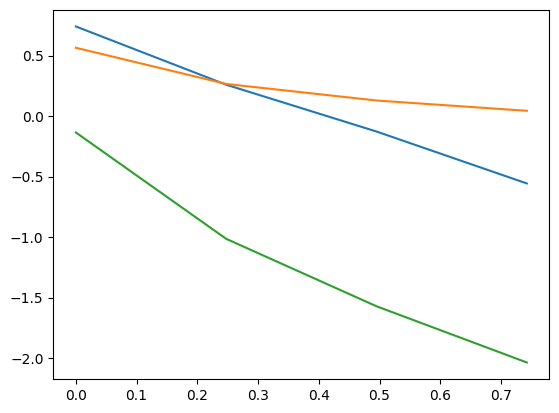

In [6]:
state_class = ['coherent']
det_modes = ['homodyne', 'heterodyne']
reconciliation_modes = ['direct', 'reverse']

from itertools import product

for states, det_mode, rec_mode in product(state_class, det_modes, reconciliation_modes):
    print(states, det_mode, rec_mode)
    plt.plot(1-T, mutual_information_CV(T, states, det_mode) - holevo_bound_CV(T, states, det_mode, rec_mode), label=f'{states}, {det_mode}, {rec_mode}')
plt.xlabel('Loss $(1 - T)$')
plt.legend()
plt.grid()


# NOT WORKING YET --> SYMP EIGVALS LESS THAN 1

# trying to generalize to coherent state protocols

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *

rate = CV_keyrate(5, T, exc_noise, alice_detection_mode='homodyne', detection_mode='heterodyne', reconciliation='reverse')
plt.plot(1-T, rate)

c:\Users\lmariani\My_Programs\github\qkd_networks\qopt_funcs.py:52: RuntimeWarning: divide by zero encountered in divide
  return np.arccosh(1+eps*T/(1-T))


ValueError: shapes (5,) and (2,2) not aligned: 5 (dim 0) != 2 (dim 0)